In [1]:
import numpy as np
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator 
import scipy as sc
import scipy.optimize as sco
import scipy.stats as sct
import scipy.spatial as scp
import MDAnalysis as mda
from tqdm import tqdm

### literature

<font size=3>
    <br>
    Paper-1: Analytical Biochemistry, Volume 317, Issue 1, 1 June 2003, Pages 40-46 <br>
    paper-2: PNAS-2006, https://doi.org/10.1073/pnas.0602650103 <br><br>

In [2]:
c = 10e-3 # 10 mM
t_b = 21.7e-6 # 21.7 micro sec

In [4]:
kd = (c * t_b) / t_u

In [5]:
kd = 9e-9
(c*t_b)/kd

24.11111111111111

In [6]:
kd = 58e-9
(c*t_b)/kd

3.7413793103448274

In [7]:
kd = 0.4e-6
(c*t_b)/kd

0.5425

In [8]:
kd = 0.6e-6
(c*t_b)/kd

0.3616666666666667

In [9]:
(10e-3 * 21.7e-6) / 50

4.34e-09

### unbinding times

#### mindists from protein

In [15]:
cut = 0.7

In [3]:
times1 = np.zeros((80))
for i in range(64):
    d = np.loadtxt(f'mindists/r{i+1}.xvg', comments=['@','#'])
    indices = np.where(d[:,1]>cut)[0]
    if len(indices)>0:
        times1[i] = d[indices[0],0]
    else:
        times1[i] = d[-1,0]

for a,i in enumerate(range(31,46+1)):
    d = np.loadtxt(f'mindists/d{i}.xvg', comments=['@','#'])
    indices = np.where(d[:,1]>cut)[0]
    if len(indices)>0:
        times1[64+a] = d[indices[0],0]
    else:
        times1[64+a] = d[-1,0]

#### cog dist > 2 or 3

In [4]:
cut = 2
times2 = np.zeros((80))
for i in range(64):
    d = np.loadtxt(f'../5_metad_runs/r{i+1}/gdm.metad')
    times2[i] = d[np.where(d[:,1]>cut)[0][0],0]

for a,i in enumerate(range(31,46+1)):
    d = np.loadtxt(f'../5_metad_runs/d{i}/gdm.metad')
    times2[64+a] = d[np.where(d[:,1]>cut)[0][0],0]

In [96]:
cut = 3
times3 = np.zeros((80))
for i in range(64):
    d = np.loadtxt(f'../5_metad_runs/r{i+1}/gdm.metad')
    times3[i] = d[np.where(d[:,1]>cut)[0][0],0]

for a,i in enumerate(range(31,46+1)):
    d = np.loadtxt(f'../5_metad_runs/d{i}/gdm.metad')
    times3[64+a] = d[np.where(d[:,1]>cut)[0][0],0]

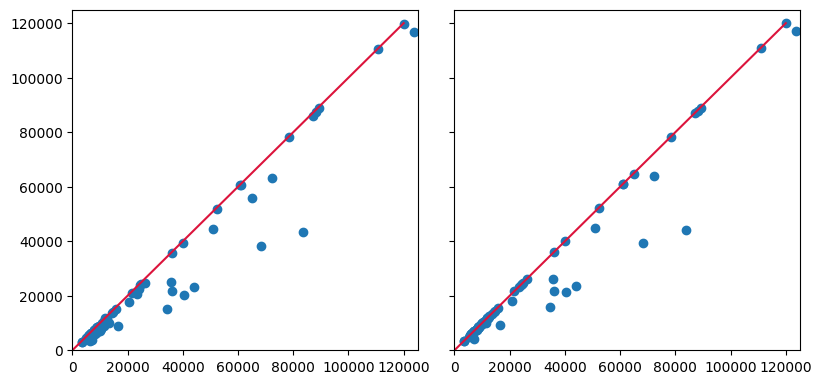

In [79]:
fig, ax = plt.subplots(1,2,figsize=(8,4), sharex=True, sharey=True)
plt.tight_layout()
ax[0].scatter(times1, times2)
ax[1].scatter(times1, times3)
ax[0].set_xlim(0,125000)
ax[0].set_ylim(0,125000)
ax[0].plot([0,120000],[0,120000], c='crimson')
ax[1].plot([0,120000],[0,120000], c='crimson')
plt.show()

#### going with the times1

In [80]:
np.savetxt('saved_results/unbinding_times1.txt', times1, fmt='%10d')

In [2]:
times1 = np.loadtxt('saved_results/unbinding_times1.txt')

### unbiased unbinding times

In [19]:
1.38e-23 * 6.022e+23 * 310.15 / 1e+3

2.577458154

In [3]:
def get_unbiased(colvar, end):
    ut = 0
    for i in colvar:
        ut += 0.02 * np.exp(i[2]/2.57)
        if i[0] > end:
            break
    return ut/1e+12

In [21]:
unbiased = np.zeros((80))
for i in range(64):
    unbiased[i] = get_unbiased(
        np.loadtxt(f'../5_metad_runs/r{i+1}/gdm.print'), times1[i]
    )
for a,i in enumerate(range(31,46+1)):
    unbiased[64+a] = get_unbiased(
        np.loadtxt(f'../5_metad_runs/d{i}/gdm.print'), times1[64+a]
    )

In [24]:
np.sort(unbiased)[[39,40]].mean()

25.392009940692077

In [22]:
np.savetxt('saved_results/unbiased.txt', unbiased, fmt='%10.5f')

In [4]:
unbiased = np.loadtxt('saved_results/unbiased.txt')

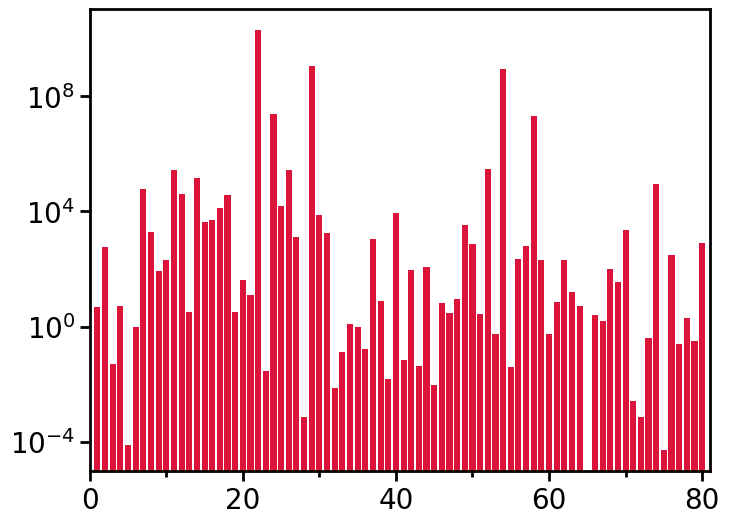

In [22]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.bar(range(1,81), unbiased, color='crimson', )
ax.set_xlim(0,81)
ax.set_xticks([0,20,40,60,80])
ax.set_yscale('log')
ax.set_yticks([1e-4,1e-0,1e4,1e8])
ax.spines[:].set_linewidth(2)
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_results/all_times.pdf')
plt.show()

In [25]:
d1 = unbiased[30:46] # 31-46 replicates
d2 = unbiased[-16:]

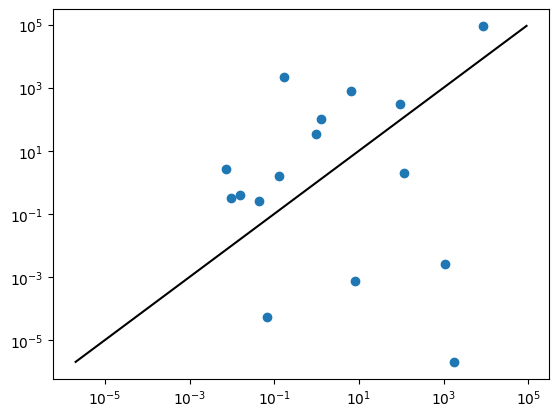

In [26]:
mini = np.concatenate((d1,d2))
maxi = mini.max()
mini = mini.min()
plt.scatter(d1,d2)
plt.xscale('log')
plt.yscale('log')
plt.plot([mini,maxi], [mini,maxi], c='black')

### fitting

In [23]:
def poisson(x,tau):
    return 1 - np.exp(-x/tau)

def ecdf1(d):
    x=np.sort(d)
    n=x.size
    y=np.arange(1,n+1)/n
    return (x,y)

def ecdf2(d,maxi):
    x=np.sort(d)
    n=x.size
    xx=[0]
    yy=[0]
    for i in range(len(x)):
        yy.append(i/n)
        yy.append((i+1)/n)
        xx.append(x[i])
        xx.append(x[i])
    xx.append(maxi)
    yy.append(1)
    xx=np.array(xx)
    yy=np.array(yy)
    return (xx,yy)

def fit_poisson(data):
    x,y = ecdf1(data)
    ftau = sco.curve_fit(poisson, x, y)[0][0]
    fitted = poisson(x,ftau)
    ks = sct.ks_2samp(fitted, y)[1]
    return ftau, ks

#### fitting with all raw data

In [28]:
fit_poisson(unbiased)

(11.22679070589204, 4.271251431273815e-08)

In [25]:
found=False
data = np.sort(unbiased)
while not found:
    tau, ks = fit_poisson(data)
    #
    if ks > 0.001:
        break
    #
    ks1 = fit_poisson(data[1:])[1]
    ks2 = fit_poisson(data[:-1])[1]
    if ks1>=ks2:
        data = data[1:]
    else:
        data=data[:-1]

tau, ks, len(data)

(11.536063116481149, 0.001124920295006686, 49)

#### (12.01442404112531, 0.01430154804770646, 40) [[if ks>0.01 is used]]

In [44]:
((10e-3*21.7e-6) / (11.5) ) * 1e9 # Kd in nM

18.869565217391305

In [36]:
((10e-3*21.7e-6) / (25.4) ) * 1e9 # based on half life time (median)

8.543307086614174

In [64]:
1/11.5 * 100 # k_off as per 10^-2

8.695652173913043

In [26]:
d=ecdf2(data, 11**4)

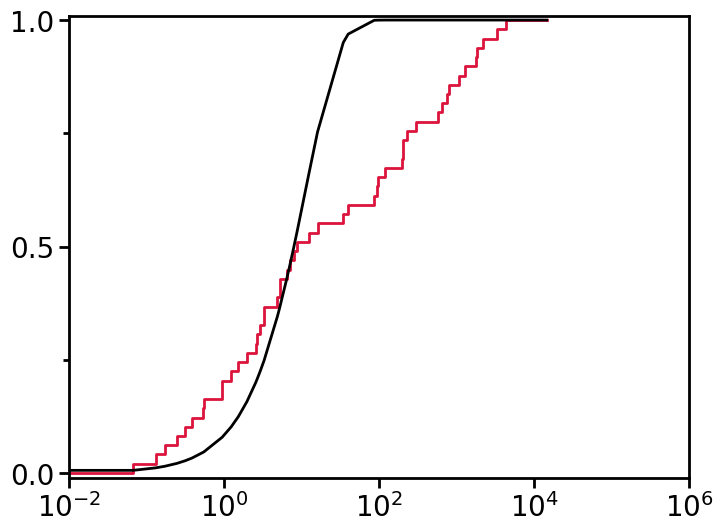

In [38]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.plot(d[0],d[1], color='crimson', lw=2)
ax.set_xscale('log')
plt.plot(d[0], poisson(d[0], tau), color='black', lw=2)
ax.set_xlim(1e-2,1e6)
ax.set_xticks([1e-2,1e0,1e2,1e4,1e6])
ax.set_ylim(-0.01,1.01)
ax.set_yticks([0,0.5,1.0])
ax.spines[:].set_linewidth(2)
ax.tick_params(labelsize=20, length=7, width=2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_results/fitted.pdf')
plt.show()

In [58]:
def bootstrap(data, subset=45, seed=None, min_ks=0.001, rounds=1000):
    np.random.seed(seed)
    btau = np.zeros((rounds))
    nobs = len(data)
    r = 0
    while r<rounds:
        sdata = data[np.random.permutation(nobs)][:subset]
        ftau, ks = fit_poisson(sdata)
        if ks >= min_ks:
            btau[r] = ftau
            r+=1
    return btau

In [59]:
btau = bootstrap(data)

In [60]:
np.mean(btau), np.std(btau)

(11.439187623454181, 1.3384421467981014)

In [62]:
((10e-3*21.7e-6) / (11.44) ) * 1e9 # Kd in nM

18.96853146853147

In [65]:
1/11.44 * 100 # k_off as per 10^-2

8.741258741258742

$k_{off} = \frac{1}{t_{u}} $ <br><br>
calculation of error <br>
$ d_{koff} = koff \times \frac{d_{tu}}{t_{u}} $ <br><br>

In [1]:
8.74 * 1.34 / 11.44

1.0237412587412589

$k_{d} = \frac{k_{off}}{k_{on}} $ <br><br>
calculation of error <br>
$ \frac{d_{kd}}{k_{d}}  = \sqrt{ (\frac{d_{koff}}{k_{off}})^2 + (\frac{d_{kon}}{k_{on}})^2 }$ <br>
<br>

In [3]:
kd = 18.97e-9
koff = 8.74e-2
d_koff = 1.02e-2
kon = 4.61e+6
d_kon = 0.38e+6
#
d_kd = kd * np.sqrt(
    (d_koff/koff)**2 + (d_kon/kon)**2
)
d_kd

2.7104296085685435e-09

### fes

In [39]:
fes = [
    np.loadtxt(f'sum_fills/r{i+1}.dat')[:,1]/4.184 for i in range(64)
] + [
    np.loadtxt(f'sum_fills/d{i}.dat')[:,1]/4.184 for i in range(31,46+1)
]

In [40]:
xb = np.loadtxt('sum_fills/r1.dat')[:,0]

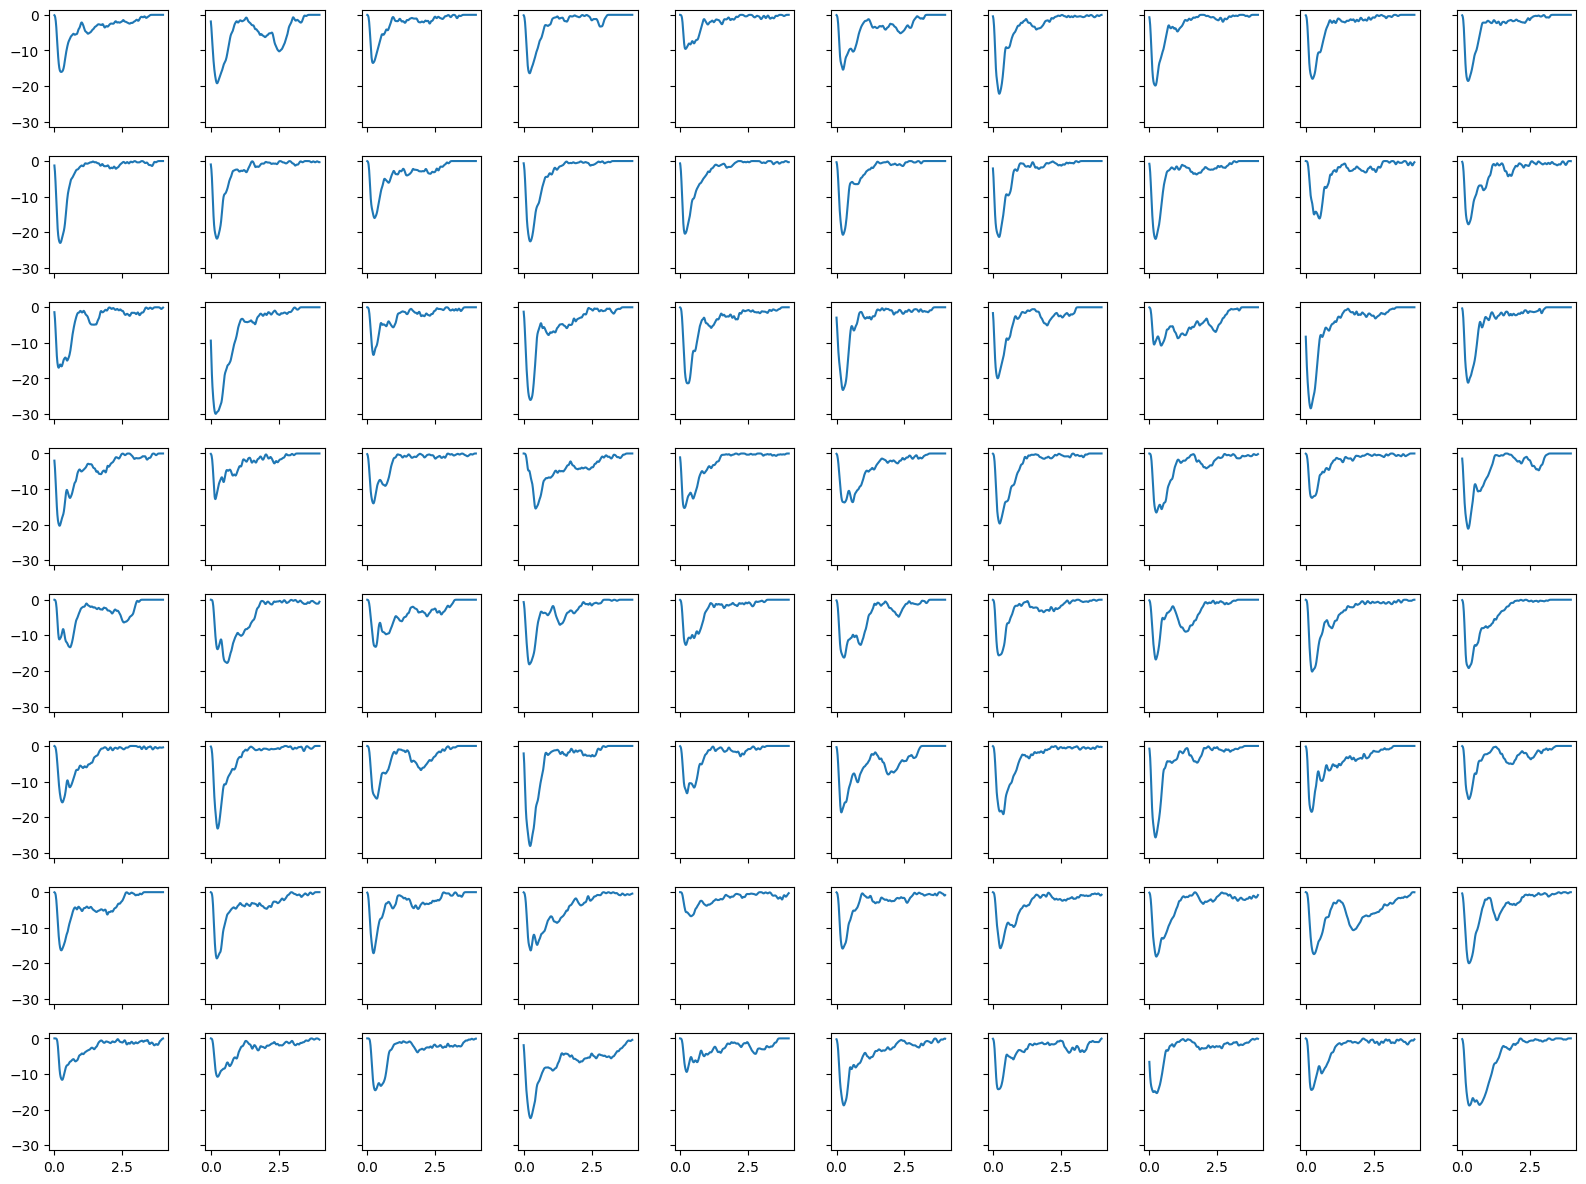

In [41]:
fig,ax=plt.subplots(8,10,figsize=(16,12), sharex=True, sharey=True)
plt.tight_layout()
ax=np.concatenate((ax))
for a,f in enumerate(fes):
    ax[a].plot(xb,f)
plt.show()

In [41]:
fmean = np.mean(fes, axis=0)
fstd = np.std(fes, axis=0)
ferr = fstd/(80-1)

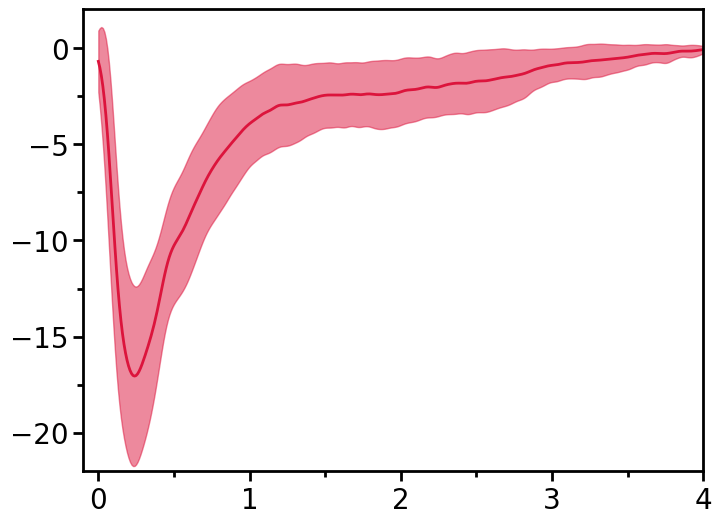

In [48]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.fill_between(xb, fmean+fstd, fmean-fstd, alpha=0.5, color='crimson')
ax.plot(xb, fmean, lw=2, color='crimson')
ax.set_xlim(-0.1,4)
ax.set_xticks([0,1,2,3,4])
ax.set_ylim(-22,2)
ax.set_yticks([-20,-15,-10,-5,0])
ax.spines[:].set_linewidth(2)
ax.tick_params(labelsize=20, length=7, width=2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_results/g_off.pdf')
plt.show()

In [80]:
uu = np.where((xb>=3.0) & (xb<=3.5))[0]
uu = np.mean(fmean[uu]), np.mean(fstd[uu]), np.mean(ferr[uu])
uu

(-0.6860845821664675, 0.8142282178500193, 0.010306686301898977)

In [81]:
bb = np.argmin(fmean)
bb = fmean[bb], fstd[bb], ferr[bb]
bb

(-17.048566434587116, 4.667587485507128, 0.05908338589249529)

In [85]:
bb[0] - uu[0],  bb[1]+uu[1], bb[2]+uu[2]

(-16.362481852420647, 5.481815703357148, 0.06939007219439426)

### pathways

In [86]:
def plot_pathway(ref, trj, cutoff, outfile,
                lig='resname GDM', 
                 out_dist=True, max_beta_dist=30, stop=np.inf):
    #
    ofile = open(outfile, 'w')
    for l in open(ref, 'r'):
        if 'ATOM ' in l[:6] and 'GDM' not in l:
            ofile.write(l)
            last = l
    ofile.write('TER \n')
    #
    items = last.strip().split()
    atom = int(items[1])+1   #for next entries
    resid = int(items[4])+1
    #
    u = mda.Universe(ref, trj)
    pos = np.mean(u.select_atoms(lig).positions, axis=0)
    ofile.write(get_line(atom, resid, pos[0], pos[1], pos[2], 0))
    atom += 1
    resid += 1
    #
    prev = [pos]
    ini = pos+0
    tlength = len(u.trajectory)
    for t in range(1, tlength):
        u.trajectory[t]
        pos = np.mean(u.select_atoms(lig).positions, axis=0)
        mindist = np.linalg.norm(np.array(prev) - pos, axis=1).min()
        if mindist > cutoff:
            if out_dist:
                beta = np.linalg.norm(ini-pos)/max_beta_dist
            else:
                beta = t/tlength
                #
            ofile.write(get_line(atom, resid, pos[0], pos[1], pos[2], beta))
            atom += 1
            resid += 1
            prev.append(pos)
        #
        if t > stop:
            break
    #
    ofile.close()


def get_coord(x):
    return (8-(len(f'{x:.3f}')))*' ' + f'{x:.3f}'

def get_line(atom, resid, xc, yc, zc, beta):
    return f'HETATM {atom:04d}  O   HOH   {resid:03d}    {get_coord(xc)}{get_coord(yc)}{get_coord(zc)}  1.00  {beta:4.2f}           O \n'

In [98]:
for i in range(64):
    plot_pathway(
        f'pbc_trjs/bound.pdb', f'pbc_trjs/r{i+1}.xtc', 
        2, f'saved_results/pathways/r{i+1}.pdb',
    )
    #
    if 31<=i<=46:
        plot_pathway(
            f'pbc_trjs/bound.pdb', f'pbc_trjs/d{i}.xtc',
            2, f'saved_results/pathways/d{i}.pdb',
            stop=times3[64+i-31]/10,
        )